# ORIE 4580/5580/5581 Assignment 6

#### Students: H. Mariappa(hm559) and T. Kigga (tck38)

### Github link: [example Github link](https://github.com/SidBanerjee/ORIE4580-Simulation/blob/main/Notebooks/Unit0-Intro_Demos.ipynb)


### Instructions


* Due Thursday, November 6, at 11.59pm on Gradescope.
* Assignment .ipynb files available for download on [Canvas](https://canvas.cornell.edu/courses/80773#:~:text=Assignments-,Assignments,-Assignments%20module%20publish). Do all your work in provided notebook (text answers typeset in markdown; show all required code and generate plots inline), and then generate and submit a pdf.
* Do all your work in provided notebook (text answers typeset in markdown; show all required code and generate plots inline), and then generate and submit a pdf.
* Ideally do assignments in groups of 2, and submit a single pdf with both names
* Please show your work and clearly mark your answers.
* You can use any code fragments given in class, found online (for example, on StackOverflow), or generated via Gemini/Claude/ChatGPT (you are encouraged to use these for first drafts) **with proper referencing**.
* You can also discuss with others (again, please reference them if you do so); but you must write your final answers on your own as a team.



### Essential reading

The chapters on [Poisson Process](https://canvas.cornell.edu/courses/80773/modules/items/3269525), [DTMCs](https://canvas.cornell.edu/courses/80773/modules/items/3426077) and [CTMCs](https://canvas.cornell.edu/courses/80773/modules/items/3426086) from Mor Harchol-Balter, posted on Canvas

<hr><hr>

# Question 1 (The Spotify Shuffle)

**(a)** (10 pts) You have a Spotify playlist with $n$ songs playing on shuffle. Suppose Spotify truly picks a random song each time -- you want to see how many songs it takes on average to play **every song** on your playlist. Build a simulator to estimate this for a different values of $n$, and use this to try and guess the function.

*Note 1*: We saw this in class as the `coupon collector' problem -- we also saw a way to compute the exact expected time in an earlier clicker question...

*Note 2*: Try and pick a large range of $n$ to get a sense of the function, and also make sure you always show your CIs!


<hr>

## Ans.

In [ ]:
import random
import math

def one_play(n):
    heard = set()
    plays = 0
    while len(heard) < n:
        song = random.randrange(n)
        heard.add(song)
        plays += 1
    return plays

def simulate_many(n, num_trials=10000):
    samples = [one_play(n) for _ in range(num_trials)]
    mean_val = sum(samples) / num_trials

    var = sum((x - mean_val)**2 for x in samples) / (num_trials - 1)
    sd = math.sqrt(var)
    se = sd / math.sqrt(num_trials)
    ci_low  = mean_val - 1.96 * se
    ci_high = mean_val + 1.96 * se
    return print(f"n={n:3d}: mean={mean_val:.2f}, 95% CI=({ci_low:.2f}, {ci_high:.2f})")

simulate_many(5)
simulate_many(10)
simulate_many(20)
simulate_many(50)
simulate_many(100)

n=  5: mean=11.40, 95% CI=(11.30, 11.50)
n= 10: mean=29.36, 95% CI=(29.14, 29.58)
n= 20: mean=71.78, 95% CI=(71.32, 72.25)
n= 50: mean=224.36, 95% CI=(223.15, 225.57)
n=100: mean=520.99, 95% CI=(518.51, 523.48)


<hr>

**(b)** (10 pts) Suppose Spotify uses the following poor randomizer: it labels songs as $\{0,1,2,\ldots,n-1\}$, and after playing a song $i$, it then either plays song $(i+1) mod(n)$ or $(i-1)mod(n)$ with probability $1/2$ (i.e., the next or previous song, imagining the songs to be in a ring with $n-1$ wrapping around to $1$). Simulate this randomizer for $n=20$, assuming you always start at song $1$, and find the histogram of the *last song to be played* for the first time using this shuffler.   


<hr>

## Ans.


In [ ]:
def one_play_new(n):
    heard = set()
    plays = 0
    i = 0
    heard.add(i)
    plays += 1

    while len(heard) < n:
        step = random.choice([-1, 1])
        if step == 1:
          next_song = (i+1) % n
        else:
          next_song = (i-1) % n
        i = next_song
        heard.add(i)
        plays += 1

    return plays

from collections import Counter

def simulate_many_new(n, num_trials=10000):
    samples = [one_play_new(n) for _ in range(num_trials)]
    mean_val = sum(samples) / num_trials

    var = sum((x - mean_val)**2 for x in samples) / (num_trials - 1)
    sd = math.sqrt(var)
    se = sd / math.sqrt(num_trials)
    ci_low  = mean_val - 1.96 * se
    ci_high = mean_val + 1.96 * se
    return print(f"n={n:3d}: mean={mean_val:.2f}, 95% CI=({ci_low:.2f}, {ci_high:.2f})")

simulate_many_new(20)


n= 20: mean=191.30, 95% CI=(189.17, 193.43)


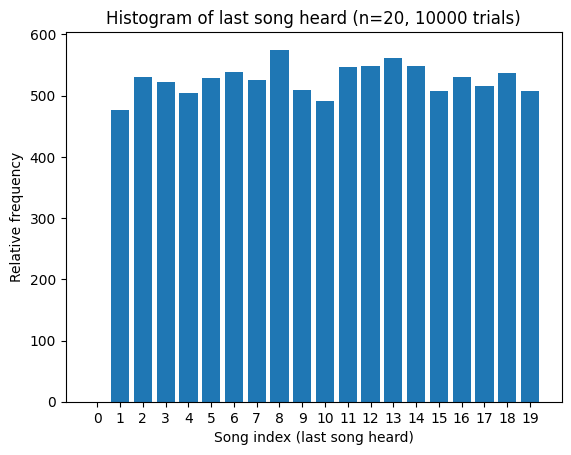

In [ ]:
import random, math
from collections import Counter
import matplotlib.pyplot as plt

def one_play_new2(n):
    heard = set()
    i = 0          # always start at song 0
    heard.add(i)

    while len(heard) < n:
        step = random.choice([-1, 1])
        if step == 1:
            next_song = (i + 1) % n
        else:
            next_song = (i - 1) % n
        i = next_song
        heard.add(i)

    return i

#used ChatGPT for a looped plotting
def last_song_histogram(n=20, num_trials=10000):
    # run the poor shuffle many times
    samples = [one_play_new2(n) for _ in range(num_trials)]

    # count how often each song is last
    counts = Counter(samples)

    # make sure every song index 0..n-1 is included
    songs = list(range(n))
    freqs = [counts[s] for s in songs]

    # plot histogram (as a bar chart)
    plt.bar(songs, freqs)
    plt.xticks(songs)
    plt.xlabel("Song index (last song heard)")
    plt.ylabel("Relative frequency")
    plt.title(f"Histogram of last song heard (n={n}, {num_trials} trials)")
    plt.show()

# example:
last_song_histogram(20, 10000)

<hr><hr>

# Question 2 (The Gambler's Ruin)


In class, we saw the balanced gambler's ruin problem: two gambler's $A$ and $B$ start with $\$a$ and $\$b$ initially, and play a sequence of games, where each game is won by either player with probability $1/2$, with the winner giving $\$ 1$ to the loser. Play goes on till one player runs out of money.

<hr>

**(a)** (5 pts) We argued that when both players have the same initial budget, then each player is equally likely to win. We now want to run a simulation to find a similar formula for general initial budgets. To do so, assume the total budget is $a+b=20$, and run simulations to find the expected probability that $A$ wins for all values of $a$ from $\{0,1,\ldots,20\}$. Plot these, and use this to conjecture what the formula may be.


<hr>

## Ans.

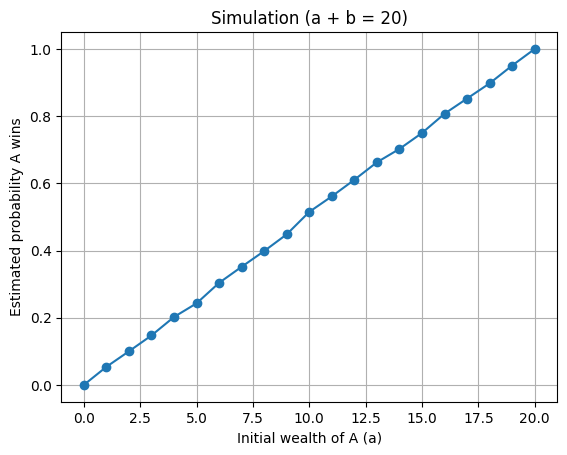

In [ ]:
def one_game(A, B):
    while A > 0 and B > 0:
        step = random.choice([-1, 1])
        if step == -1:
            A += 1
            B -= 1
        else:
            A -= 1
            B += 1

    return A > 0


def A_wins(a, b, trials):
    wins = sum(one_game(a, b) for _ in range(trials))
    return wins / trials

probs = []

for a in range(21):
    b = 20 - a
    p = A_wins(a, b, 5000)
    probs.append(p)


plt.plot(range(21), probs, marker='o')
plt.xlabel("Initial wealth of A (a)")
plt.ylabel("Estimated probability A wins")
plt.title("Simulation (a + b = 20)")
plt.grid(True)
plt.show()

The formula can be found from taking the slope of the line above. The probability of A winning = slope(initial A). In this case the slope is 0.053. The number for B is not accounted as B is derived from initial A from 20 - A, there is only one variable so it must be linear.

**(b)** (10 pts) Another question we can ask is how long it takes for either player to get ruined. To study this, simulate the gambler's ruin for a range of values of $a$ and $b$, and use this to try and guess the expected time to ruin.

Note: Convince yourself that the function must be symmetric in $a$ and $b$, so you can assume $a\leq b$. Try plotting the expected absorption times for selected values of $a$, while varying $b$.


<hr>

## Ans.

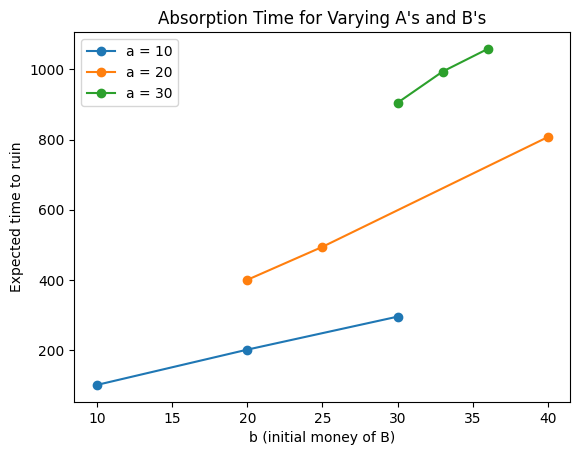

In [ ]:
#Random numbers chosen
plot_1_a = 10
plot_2_a = 20
plot_3_a = 30

plot_1_b = [10, 20, 30]
plot_2_b = [20, 25, 40]
plot_3_b = [30, 33, 36]


def one_game_time(a, b):
    t = 0

    while a > 0 and b > 0:
        t += 1
        if random.random() < 0.5:
            a += 1
            b -= 1
        else:
            a -= 1
            b += 1
    return t

def expected_time_to_ruin(a, b, num_trials=5000):
    times = []
    for _ in range(num_trials):
        t = one_game_time(a, b)
        times.append(t)
    return np.mean(times)

def plot_absorption_times(num_trials=5000):
    configs = [
        (plot_1_a, plot_1_b),
        (plot_2_a, plot_2_b),
        (plot_3_a, plot_3_b),
    ]

    for a, b_values in configs:
        mean_times = [expected_time_to_ruin(a, b, num_trials) for b in b_values]
        plt.plot(b_values, mean_times, marker='o', label=f"a = {a}")

    plt.xlabel("b (initial money of B)")
    plt.ylabel("Expected time to ruin")
    plt.title("Absorption Time for Varying A's and B's")
    plt.legend()
    plt.show()

plot_absorption_times()


expected time = A*B

both the the variables are included as the variables are no longer dependent on each other.

<hr>

**(c)** (OPTIONAL) For parts $(a)$ and $(b)$, try and theoretically prove what you observe from your simulations!


<hr>

## Ans.

<hr><hr>

# Question 3 (Staffing a hospital)


Consider the model of the Fingerlakes Regional Hospital as shown below. New patients arrive at the reception at a rate of 20/hr and emergency patients enter the ER at a rate of 5/hr. The reception desk for non-emergency patients is managed by $n_R$ associates. Admission at the reception (not counting any queueing time) takes 5 minutes on average, regardless of whether the non-emergency patient is first-time or returning. The clinic is served by $d_C$ doctors with an average visit time of 15 minutes. About one in every four patients visiting the clinic are asked to return for a follow-up appointment that is, on average, 3 weeks (504 hours) later in time; another one-tenth of visitors to the clinic are referred to the internal ward (IW); the rest are treated and discharged. Patients arriving to the ER require about 1 hour of time with a doctor. The ER is staffed by $d_E$ doctors. Half of the patients in the ER are discharged after treatment, with the remainder referred to the IW. The average stay in the IW is about 72 hours and there are $n_I$ IW beds available. After a stay at the IW, 20\% of patients are discharged, whereas the rest are asked to return for a follow-up appointment as a non-emergency patient that is, on average, 3 weeks (504 hours) later in time. The reception, clinic, ER and IW all have their separate waiting areas and wait-lists, and serve patients on a FCFS basis.


![hwq2figure.png](attachment:hwq2figure.png)

**(a)** (5 pts)  Find bounds on the number of receptionists $n_R$, IW beds $N_I$, clinic doctors $d_C$ and ER doctors $d_E$ that the hospital requires to ensure it can keep up with its patient load?

<hr>

## Ans.
From the data given to us: $\lambda_ER$ = New ER Patients = 5/hour and $\lambda_N$ = New Patients = 20/hour.

Flow to recepetionist = new patients + clinic followup + IW Followup = 20+0.25$\lambda_c$ + 0.8(IW admission rate) = 20 + 0.25$\lambda_c$ + 0.8*(0.1$\lambda_R$ + 2.5). Since we know that $\lambda_R$ = $\lambda_c$ = 32.84 patients/hour. IW admission rate = (0.1*32.84) + 2.5 = 5.78 patients/hour.

Number of receptionists $n_R$: Since we know that the receptionist takes 5 mins to admit then we can admit (60/5) = 12 patients/hour. Therefore, $N_r$ >= $\frac{32.84}{12}$ = 2.736. $N_r \ge 3$

IW beds $N_I$: IW admission rate = 5.78 patients/hour. Average stay = 72 hours. 5.78* 72 = 416.42 patinets. Therefore, $N_1 \ge 417 beds$

Clinic doctors $d_C$: Average visits time is 15 mins which means 4 doctors/hour. $d_c$ >= $\frac{32.84}{4}$ = 8.209. $d_c \ge 9$

ER doctors $d_E$: 1 hour time with doctor. $d_E$ >= $\frac{5}{1}$ = 5. $d_E \ge 6$





<hr>

**(b)** (10 pts) Suppose the hospital chooses to run with $d_E=7$ doctors in the ER, $d_C=10$ doctors in the clinic, and $n=500$ beds in the IW. Approximate the average time spent in the clinic (including treatment but not including reception) and the average number of busy clinic doctors.

<hr>

## Ans.
We know that $d_E=7$ doctors in the ER and $d_C=10$ doctors in teh clinic and N = 500 Beds in the IW. From schotasic class we know that there is an M/M.10 queue for the clinic. We can use the Erlang C formula which are: $a = \frac{lambda}{mu}$ and $p = \frac{a}{c}$: $a = \frac{32.84}{4} = 8.21$ and $p = \frac{8.21}{10} = 0.821$.

The $P_{\text{wait}}$ formula for Erlang C is:

$$
P_{\text{wait}} \;=\;
\frac{\dfrac{(a)^c}{c!\,(c-a)}}
{\displaystyle\sum_{k=0}^{N-1} \frac{a^k}{k!}
\;+\;
\dfrac{(a)^c}{c!\,(c-a)} }
$$
To solve this we will replace the values: $$
P_{\text{wait}} \;=\;
\frac{\dfrac{(8.21)^10}{10!\,(10-8.21)}}
{\displaystyle\sum_{k=0}^{9} \frac{8.21^k}{k!}
\;+\;
\dfrac{(8.21)^10}{10!\,(10-8.21)} } = 0.4576
$$

The average number of busy clinic doctors = 8.21
Average time spent in clinic: $$ W_{\text{q}} = \frac{Pwait}{(C*Mu)-lambda}=  \frac{0.4576}{(10*4)-32.84} = 3.83 minutes$$

Total time spent waiting: $$W_{\text{q}} + \frac{1}{4} = 18.83 minutes $$




<hr>

**(c)** (10 pts) Suppose the hospital chooses to run with $d_E=7$ doctors in the ER, $d_C=10$ doctors in the clinic, and $n=500$ beds in the IW. Compute the probability that the hospital will simultaneously have no patients in the ER and no patients in the clinic.

<hr>

## Ans.

We know that the clinic queue is M/M/10 and ER queue is M/M/7

$$P(Clinicempty and ER empty) = P_{\text{0,clinic}} * P_{\text{0,ER}}$$
The $P_0$ (normalizing constant) for Erlang C is:

$$
P_0 =
\left[
\sum_{k=0}^{N-1} \frac{(a)^k}{k!}
\;+\;
\frac{(a)^C}{C!\,(1-\rho)}
\right]^{-1}
$$

$$
P_0(clinic) =
\left[
\sum_{k=0}^{9} \frac{(8.21)^k}{k!}
\;+\;
\frac{(8.21)^10}{10!\,(1-0.821)}
\right]^{-1} = 2.14 * 10^{-4}
$$

We calculated a = 5/1 = 5.

p = 5/7 = 0.7143
$$
P_0(ER) =
\left[
\sum_{k=0}^{6} \frac{(5)^k}{k!}
\;+\;
\frac{(5)^7}{7!\,(1-0.7143)}
\right]^{-1} = 5.97 * 10^{-3}
$$

Therefore: $$P(Clinicempty and ER empty) = 2.14 * 10^{-4} * 5.97 * 10^{-3} = 1.28 * 10^{-6}$$

<hr>

**(d)** (40 pts) Build a simulator for the above model, assuming the external arrivals to the reception and ER are Poisson processes, and all service times are exponential and all routings are independent. You can re-use any of the code we provided in the recitations.

Use your simulator to study the following:

$(i)$ Plot the total number of patients waiting in the hospital when the number of doctors and beds is $1$ more than your suggestions in part $(a)$, and when it is $1$ less than your suggestions in part $(a)$. You should simulate over a long enough time horizon to be able to determine whether the numbers stabilize, or grow unbounded.

$(ii)$ Simulate the configuration in part $(b)$, and plot the average time spent by patients in the clinic, and the average number of busy clinic doctors. How do these compare to the answers in part $(b)$?

<hr>

## Ans.


PART (a): MINIMUM RESOURCE REQUIREMENTS
Based on your stability analysis:
  • Receptionists (nR) ≥ 3
  • Clinic Doctors (dC) ≥ 9
  • ER Doctors (dE) ≥ 6
  • IW Beds (nI) ≥ 417

PART (d)(i): STABILITY ANALYSIS

Simulating configurations:
  • 1 Less than minimum: R=2, C=8, E=5, IW=416
  • Minimum (Part a): R=3, C=9, E=6, IW=417
  • 1 More than minimum: R=4, C=10, E=7, IW=418

Running simulation (this may take a minute)...


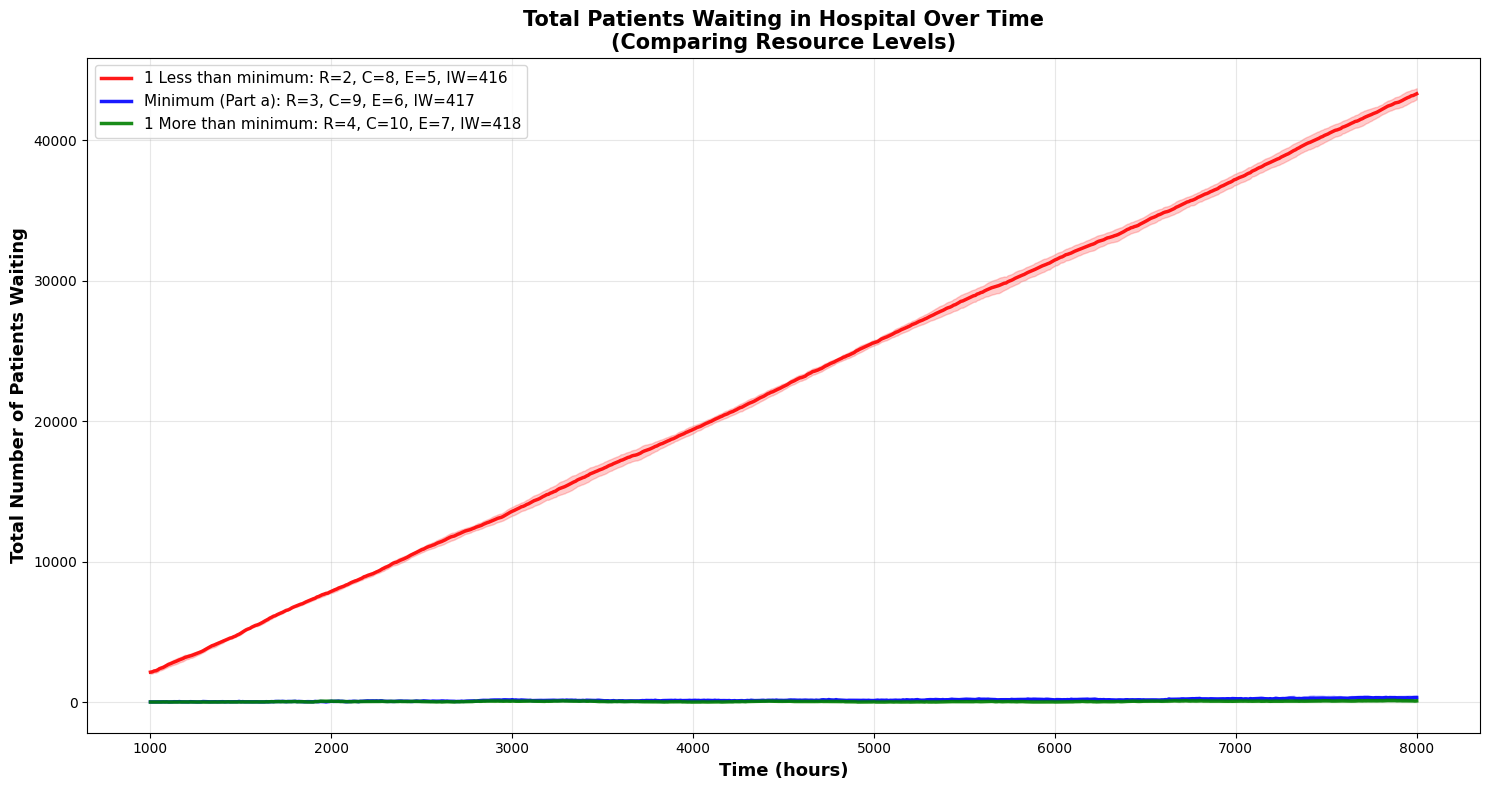


✓ Plot generated for Part (d)(i)

Interpretation:
  • RED curve: Should show unbounded growth (unstable)
  • BLUE curve: Should stabilize (marginally stable)
  • GREEN curve: Should stabilize at lower levels (stable)

PART (d)(ii): CLINIC PERFORMANCE ANALYSIS

Configuration from Part (b):
  • Receptionists: 3
  • Clinic Doctors: 10
  • ER Doctors: 7
  • IW Beds: 500

Your Theoretical Results from Part (b):
  • Average wait time (Wq): 3.83 minutes
  • Average total time in clinic: 18.83 minutes
  • Average busy clinic doctors: 8.21

Running simulation (this may take a minute)...


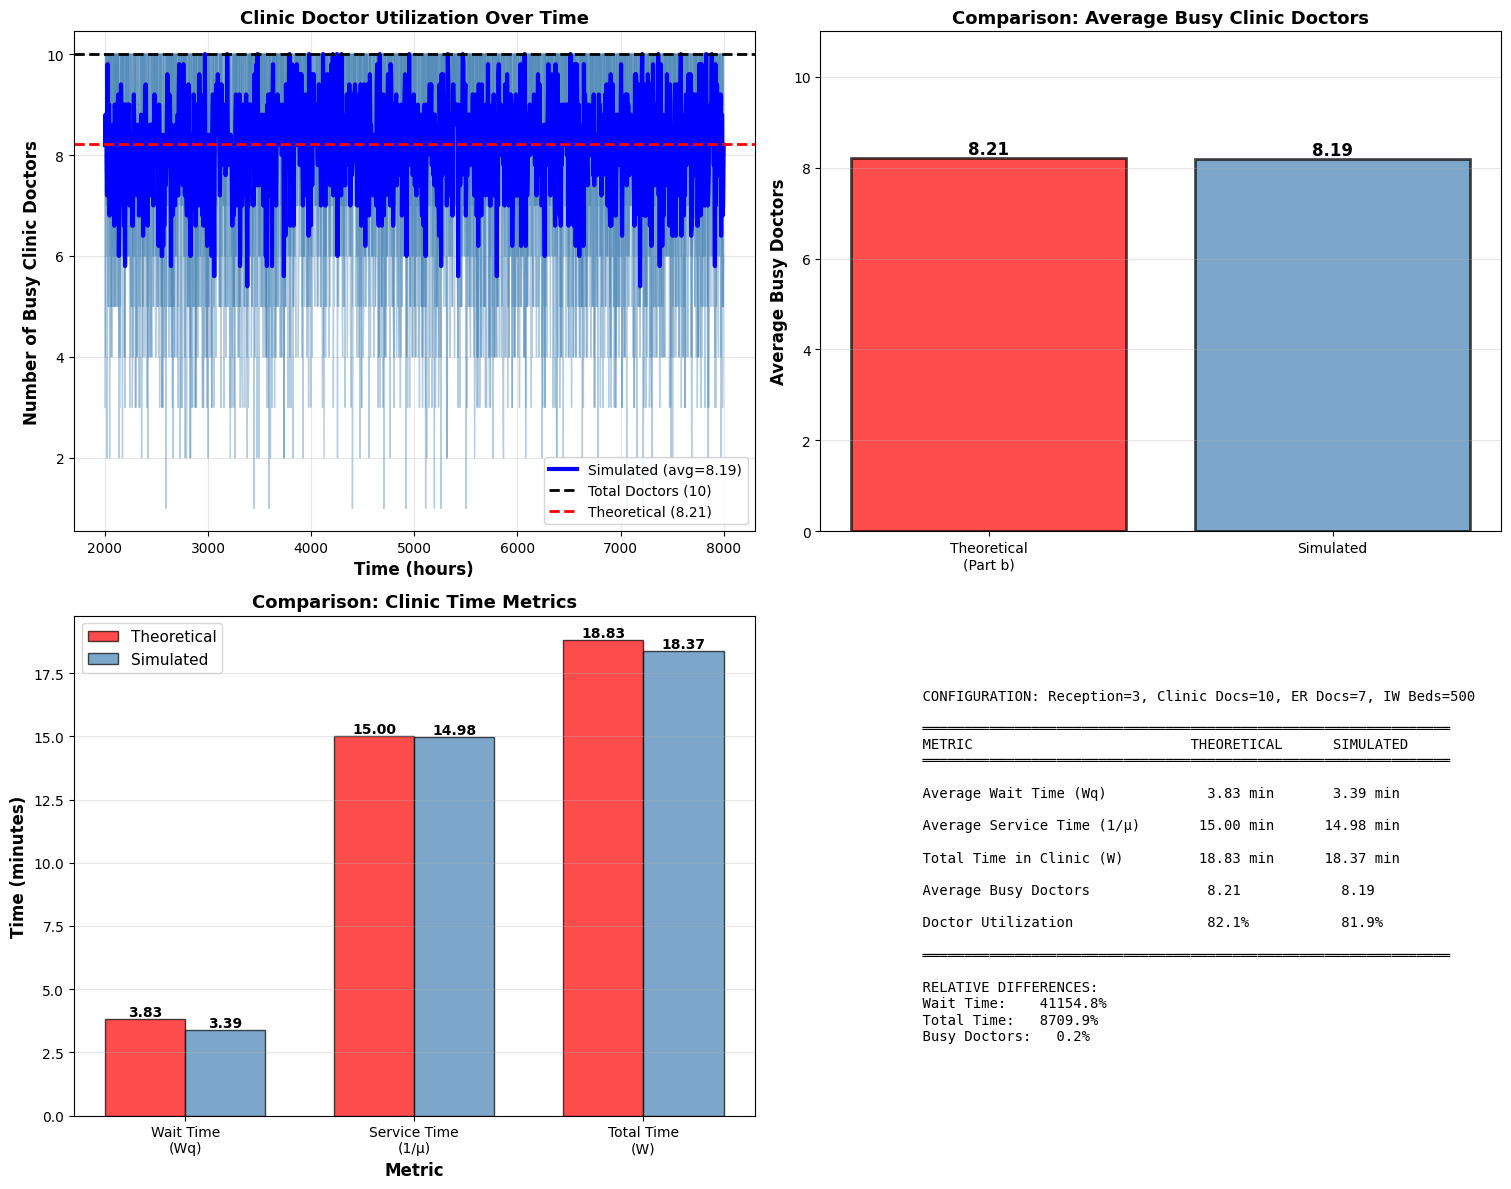


✓ Plots generated for Part (d)(ii)

SIMULATION RESULTS SUMMARY

Average wait time in queue:    3.39 ± 0.05 minutes
Average service time:          14.98 ± 0.03 minutes
Average total time in clinic:  18.37 ± 0.06 minutes
Average busy clinic doctors:   8.19 ± 0.05
Doctor utilization:            81.9%

COMPARISON WITH THEORETICAL (Part b)

Busy Doctors:
  Theoretical: 8.21
  Simulated:   8.19
  Difference:  0.2%

Wait Time:
  Theoretical: 3.83 min
  Simulated:   3.39 min
  Difference:  11.4%

Total Time in Clinic:
  Theoretical: 18.83 min
  Simulated:   18.37 min
  Difference:  2.4%

✓ SIMULATION COMPLETE


In [ ]:
#Chat GPT was used to create this code
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
import heapq
from dataclasses import dataclass
from typing import List, Tuple
import pandas as pd

@dataclass
class Patient:
    """Represents a patient in the system"""
    id: int
    arrival_time: float
    patient_type: str  # 'new', 'emergency', 'followup'
    current_location: str
    entry_time: float  # time entered current location
    service_start_time: float = None
    history: List[Tuple[str, float, float]] = None  # (location, entry_time, exit_time)

    def __post_init__(self):
        if self.history is None:
            self.history = []

@dataclass
class Event:
    """Represents an event in the simulation"""
    time: float
    event_type: str
    patient: Patient = None
    location: str = None

    def __lt__(self, other):
        return self.time < other.time

class HospitalSimulator:
    def __init__(self, n_reception, n_clinic_docs, n_er_docs, n_iw_beds,
                 arrival_rate_reception=20.0, arrival_rate_er=5.0):
        """
        Initialize hospital simulator

        Parameters:
        - n_reception: number of reception associates
        - n_clinic_docs: number of clinic doctors
        - n_er_docs: number of ER doctors
        - n_iw_beds: number of internal ward beds
        - arrival_rate_reception: external arrival rate to reception (per hour)
        - arrival_rate_er: external arrival rate to ER (per hour)
        """
        self.n_reception = n_reception
        self.n_clinic_docs = n_clinic_docs
        self.n_er_docs = n_er_docs
        self.n_iw_beds = n_iw_beds

        self.arrival_rate_reception = arrival_rate_reception
        self.arrival_rate_er = arrival_rate_er

        # Service rates (per hour)
        self.service_rate_reception = 12.0  # 5 min = 12/hr
        self.service_rate_clinic = 4.0      # 15 min = 4/hr
        self.service_rate_er = 1.0          # 1 hr
        self.service_rate_iw = 1.0/72.0     # 72 hrs

        # Routing probabilities
        self.prob_clinic_followup = 0.25
        self.prob_clinic_to_iw = 0.10
        self.prob_clinic_discharge = 0.65

        self.prob_er_discharge = 0.50
        self.prob_er_to_iw = 0.50

        self.prob_iw_discharge = 0.20
        self.prob_iw_followup = 0.80

        self.followup_delay = 504.0  # hours

        # State variables
        self.current_time = 0.0
        self.patient_counter = 0

        # Queues (waiting patients)
        self.queue_reception = []
        self.queue_clinic = []
        self.queue_er = []
        self.queue_iw = []

        # Servers (patients being served)
        self.busy_reception = []
        self.busy_clinic = []
        self.busy_er = []
        self.busy_iw = []

        # Event queue
        self.event_queue = []

        # Statistics collection
        self.total_patients_in_system = []
        self.time_points = []

        self.clinic_wait_times = []
        self.clinic_service_times = []
        self.clinic_total_times = []  # wait + service
        self.clinic_busy_docs = []
        self.clinic_time_points = []

    def schedule_event(self, event: Event):
        """Add event to the event queue"""
        heapq.heappush(self.event_queue, event)

    def generate_exponential(self, rate):
        """Generate exponential random variable"""
        return np.random.exponential(1.0/rate) if rate > 0 else float('inf')

    def create_patient(self, patient_type):
        """Create a new patient"""
        self.patient_counter += 1
        return Patient(
            id=self.patient_counter,
            arrival_time=self.current_time,
            patient_type=patient_type,
            current_location='',
            entry_time=self.current_time
        )

    def initialize(self):
        """Initialize the simulation"""
        # Schedule first external arrivals
        next_arrival_reception = self.generate_exponential(self.arrival_rate_reception)
        self.schedule_event(Event(next_arrival_reception, 'arrival_reception'))

        next_arrival_er = self.generate_exponential(self.arrival_rate_er)
        self.schedule_event(Event(next_arrival_er, 'arrival_er'))

    def record_statistics(self):
        """Record current state statistics"""
        total_waiting = (len(self.queue_reception) + len(self.queue_clinic) +
                        len(self.queue_er) + len(self.queue_iw))

        self.total_patients_in_system.append(total_waiting)
        self.time_points.append(self.current_time)

        # Clinic-specific statistics
        self.clinic_busy_docs.append(len(self.busy_clinic))
        self.clinic_time_points.append(self.current_time)

    def handle_arrival_reception(self):
        """Handle external arrival to reception"""
        patient = self.create_patient('new')
        self.arrival_to_reception(patient)

        # Schedule next external arrival
        next_arrival = self.current_time + self.generate_exponential(self.arrival_rate_reception)
        self.schedule_event(Event(next_arrival, 'arrival_reception'))

    def handle_arrival_er(self):
        """Handle external arrival to ER"""
        patient = self.create_patient('emergency')
        self.arrival_to_er(patient)

        # Schedule next external arrival
        next_arrival = self.current_time + self.generate_exponential(self.arrival_rate_er)
        self.schedule_event(Event(next_arrival, 'arrival_er'))

    def arrival_to_reception(self, patient):
        """Patient arrives to reception"""
        patient.current_location = 'reception'
        patient.entry_time = self.current_time

        if len(self.busy_reception) < self.n_reception:
            # Start service immediately
            patient.service_start_time = self.current_time
            self.busy_reception.append(patient)
            service_time = self.generate_exponential(self.service_rate_reception)
            self.schedule_event(Event(self.current_time + service_time,
                                    'departure_reception', patient))
        else:
            # Join queue
            self.queue_reception.append(patient)

    def arrival_to_clinic(self, patient):
        """Patient arrives to clinic"""
        patient.current_location = 'clinic'
        clinic_entry_time = self.current_time
        patient.clinic_entry = clinic_entry_time  # Track clinic entry

        if len(self.busy_clinic) < self.n_clinic_docs:
            # Start service immediately
            patient.service_start_time = self.current_time
            self.busy_clinic.append(patient)
            service_time = self.generate_exponential(self.service_rate_clinic)
            self.schedule_event(Event(self.current_time + service_time,
                                    'departure_clinic', patient))
        else:
            # Join queue
            self.queue_clinic.append(patient)

    def arrival_to_er(self, patient):
        """Patient arrives to ER"""
        patient.current_location = 'er'
        patient.entry_time = self.current_time

        if len(self.busy_er) < self.n_er_docs:
            # Start service immediately
            patient.service_start_time = self.current_time
            self.busy_er.append(patient)
            service_time = self.generate_exponential(self.service_rate_er)
            self.schedule_event(Event(self.current_time + service_time,
                                    'departure_er', patient))
        else:
            # Join queue
            self.queue_er.append(patient)

    def arrival_to_iw(self, patient):
        """Patient arrives to IW"""
        patient.current_location = 'iw'
        patient.entry_time = self.current_time

        if len(self.busy_iw) < self.n_iw_beds:
            # Start service immediately
            patient.service_start_time = self.current_time
            self.busy_iw.append(patient)
            service_time = self.generate_exponential(self.service_rate_iw)
            self.schedule_event(Event(self.current_time + service_time,
                                    'departure_iw', patient))
        else:
            # Join queue
            self.queue_iw.append(patient)

    def handle_departure_reception(self, patient):
        """Handle departure from reception"""
        # Remove from busy list
        self.busy_reception.remove(patient)

        # Patient goes to clinic
        self.arrival_to_clinic(patient)

        # Start serving next patient in queue
        if self.queue_reception:
            next_patient = self.queue_reception.pop(0)
            next_patient.service_start_time = self.current_time
            self.busy_reception.append(next_patient)
            service_time = self.generate_exponential(self.service_rate_reception)
            self.schedule_event(Event(self.current_time + service_time,
                                    'departure_reception', next_patient))

    def handle_departure_clinic(self, patient):
        """Handle departure from clinic"""
        # Record statistics
        if patient.service_start_time is not None:
            service_time = self.current_time - patient.service_start_time
            self.clinic_service_times.append(service_time)

            # Total time in clinic (wait + service)
            if hasattr(patient, 'clinic_entry'):
                total_time = self.current_time - patient.clinic_entry
                self.clinic_total_times.append(total_time)

                # Wait time
                wait_time = patient.service_start_time - patient.clinic_entry
                self.clinic_wait_times.append(wait_time)

        # Remove from busy list
        self.busy_clinic.remove(patient)

        # Routing decision
        rand = np.random.random()
        if rand < self.prob_clinic_followup:
            # Schedule follow-up
            followup_time = self.current_time + self.followup_delay
            patient.patient_type = 'followup'
            self.schedule_event(Event(followup_time, 'followup_arrival', patient))
        elif rand < self.prob_clinic_followup + self.prob_clinic_to_iw:
            # Go to IW
            self.arrival_to_iw(patient)
        # else: discharged

        # Start serving next patient in queue
        if self.queue_clinic:
            next_patient = self.queue_clinic.pop(0)
            next_patient.service_start_time = self.current_time
            self.busy_clinic.append(next_patient)
            service_time = self.generate_exponential(self.service_rate_clinic)
            self.schedule_event(Event(self.current_time + service_time,
                                    'departure_clinic', next_patient))

    def handle_departure_er(self, patient):
        """Handle departure from ER"""
        # Remove from busy list
        self.busy_er.remove(patient)

        # Routing decision
        if np.random.random() < self.prob_er_to_iw:
            # Go to IW
            self.arrival_to_iw(patient)
        # else: discharged

        # Start serving next patient in queue
        if self.queue_er:
            next_patient = self.queue_er.pop(0)
            next_patient.service_start_time = self.current_time
            self.busy_er.append(next_patient)
            service_time = self.generate_exponential(self.service_rate_er)
            self.schedule_event(Event(self.current_time + service_time,
                                    'departure_er', next_patient))

    def handle_departure_iw(self, patient):
        """Handle departure from IW"""
        # Remove from busy list
        self.busy_iw.remove(patient)

        # Routing decision
        if np.random.random() < self.prob_iw_followup:
            # Schedule follow-up
            followup_time = self.current_time + self.followup_delay
            patient.patient_type = 'followup'
            self.schedule_event(Event(followup_time, 'followup_arrival', patient))
        # else: discharged

        # Start serving next patient in queue
        if self.queue_iw:
            next_patient = self.queue_iw.pop(0)
            next_patient.service_start_time = self.current_time
            self.busy_iw.append(next_patient)
            service_time = self.generate_exponential(self.service_rate_iw)
            self.schedule_event(Event(self.current_time + service_time,
                                    'departure_iw', next_patient))

    def handle_followup_arrival(self, patient):
        """Handle follow-up appointment arrival"""
        self.arrival_to_reception(patient)

    def run(self, sim_time, record_interval=1.0, warmup=0):
        """
        Run the simulation

        Parameters:
        - sim_time: total simulation time
        - record_interval: interval for recording statistics
        - warmup: warmup period (statistics collected after this time)
        """
        self.initialize()

        next_record_time = record_interval

        while self.event_queue and self.current_time < sim_time:
            # Get next event
            event = heapq.heappop(self.event_queue)
            self.current_time = event.time

            if self.current_time > sim_time:
                break

            # Record statistics at intervals (after warmup)
            while next_record_time <= self.current_time:
                if self.current_time >= warmup:
                    self.record_statistics()
                next_record_time += record_interval

            # Handle event
            if event.event_type == 'arrival_reception':
                self.handle_arrival_reception()
            elif event.event_type == 'arrival_er':
                self.handle_arrival_er()
            elif event.event_type == 'departure_reception':
                self.handle_departure_reception(event.patient)
            elif event.event_type == 'departure_clinic':
                self.handle_departure_clinic(event.patient)
            elif event.event_type == 'departure_er':
                self.handle_departure_er(event.patient)
            elif event.event_type == 'departure_iw':
                self.handle_departure_iw(event.patient)
            elif event.event_type == 'followup_arrival':
                self.handle_followup_arrival(event.patient)

        # Final statistics
        if self.current_time >= warmup:
            self.record_statistics()

# ============================================================================
# ANALYSIS FUNCTIONS
# ============================================================================

def plot_total_waiting_comparison(configs, labels, sim_time=10000, num_runs=5):
    """
    Plot total number of patients waiting for different configurations
    """
    plt.figure(figsize=(15, 8))

    colors = ['red', 'blue', 'green']

    for idx, (config, label) in enumerate(zip(configs, labels)):
        n_r, n_c, n_e, n_i = config

        # Run multiple replications
        all_waiting = []
        common_times = None

        for run in range(num_runs):
            np.random.seed(42 + run)
            sim = HospitalSimulator(n_r, n_c, n_e, n_i)
            sim.run(sim_time, record_interval=10.0, warmup=1000)

            if common_times is None:
                common_times = sim.time_points

            all_waiting.append(sim.total_patients_in_system)

        # Average across runs
        avg_waiting = np.mean(all_waiting, axis=0)
        std_waiting = np.std(all_waiting, axis=0)

        plt.plot(common_times, avg_waiting, label=label, linewidth=2.5,
                color=colors[idx], alpha=0.9)
        plt.fill_between(common_times,
                        np.maximum(0, avg_waiting - std_waiting),
                        avg_waiting + std_waiting,
                        alpha=0.2, color=colors[idx])

    plt.xlabel('Time (hours)', fontsize=13, fontweight='bold')
    plt.ylabel('Total Number of Patients Waiting', fontsize=13, fontweight='bold')
    plt.title('Total Patients Waiting in Hospital Over Time\n(Comparing Resource Levels)',
              fontsize=15, fontweight='bold')
    plt.legend(fontsize=11, loc='best')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

def analyze_clinic_performance(n_reception, n_clinic_docs, n_er_docs, n_iw_beds,
                               sim_time=10000, num_runs=5, warmup=2000):
    """
    Analyze clinic performance: average time spent and busy doctors
    """
    all_avg_wait_times = []
    all_avg_service_times = []
    all_avg_total_times = []
    all_busy_docs = []
    all_busy_time_series = []

    for run in range(num_runs):
        np.random.seed(100 + run)
        sim = HospitalSimulator(n_reception, n_clinic_docs, n_er_docs, n_iw_beds)
        sim.run(sim_time, record_interval=5.0, warmup=warmup)

        # Calculate average times in clinic
        if sim.clinic_wait_times:
            all_avg_wait_times.append(np.mean(sim.clinic_wait_times))
        if sim.clinic_service_times:
            all_avg_service_times.append(np.mean(sim.clinic_service_times))
        if sim.clinic_total_times:
            all_avg_total_times.append(np.mean(sim.clinic_total_times))

        # Average number of busy doctors
        all_busy_docs.append(np.mean(sim.clinic_busy_docs))
        all_busy_time_series.append(sim.clinic_busy_docs)

    results = {
        'avg_wait_time_hours': np.mean(all_avg_wait_times) if all_avg_wait_times else 0,
        'std_wait_time_hours': np.std(all_avg_wait_times) if all_avg_wait_times else 0,
        'avg_service_time_hours': np.mean(all_avg_service_times) if all_avg_service_times else 0,
        'std_service_time_hours': np.std(all_avg_service_times) if all_avg_service_times else 0,
        'avg_total_time_hours': np.mean(all_avg_total_times) if all_avg_total_times else 0,
        'std_total_time_hours': np.std(all_avg_total_times) if all_avg_total_times else 0,
        'avg_busy_docs': np.mean(all_busy_docs) if all_busy_docs else 0,
        'std_busy_docs': np.std(all_busy_docs) if all_busy_docs else 0,
        'time_series_busy': all_busy_time_series
    }

    return results

def plot_clinic_performance(config, sim_time=10000, num_runs=5, warmup=2000):
    """
    Plot clinic-specific performance metrics and compare with theoretical values
    """
    n_r, n_c, n_e, n_i = config
    results = analyze_clinic_performance(n_r, n_c, n_e, n_i, sim_time, num_runs, warmup)

    # Theoretical values from your part (b)
    theoretical_busy_docs = 8.21
    theoretical_wait_time = 3.83 / 60  # Convert minutes to hours
    theoretical_total_time = 18.83 / 60  # Convert minutes to hours

    fig, axes = plt.subplots(2, 2, figsize=(16, 12))

    # Plot 1: Average number of busy doctors over time
    ax1 = axes[0, 0]
    for idx, run_data in enumerate(results['time_series_busy']):
        time_points = np.linspace(warmup, sim_time, len(run_data))
        ax1.plot(time_points, run_data, alpha=0.4, linewidth=1, color='steelblue')

    # Plot average across runs
    avg_busy = np.mean(results['time_series_busy'], axis=0)
    time_points = np.linspace(warmup, sim_time, len(avg_busy))
    ax1.plot(time_points, avg_busy, 'b-', linewidth=3, label=f'Simulated (avg={results["avg_busy_docs"]:.2f})')
    ax1.axhline(y=n_c, color='black', linestyle='--', linewidth=2, label=f'Total Doctors ({n_c})')
    ax1.axhline(y=theoretical_busy_docs, color='red', linestyle='--', linewidth=2,
               label=f'Theoretical ({theoretical_busy_docs:.2f})')

    ax1.set_xlabel('Time (hours)', fontsize=12, fontweight='bold')
    ax1.set_ylabel('Number of Busy Clinic Doctors', fontsize=12, fontweight='bold')
    ax1.set_title('Clinic Doctor Utilization Over Time', fontsize=13, fontweight='bold')
    ax1.legend(fontsize=10)
    ax1.grid(True, alpha=0.3)

    # Plot 2: Bar chart comparing busy doctors
    ax2 = axes[0, 1]
    categories = ['Theoretical\n(Part b)', 'Simulated']
    values = [theoretical_busy_docs, results['avg_busy_docs']]
    colors_bar = ['red', 'steelblue']
    bars = ax2.bar(categories, values, color=colors_bar, alpha=0.7, edgecolor='black', linewidth=2)

    # Add value labels on bars
    for bar in bars:
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.2f}',
                ha='center', va='bottom', fontsize=12, fontweight='bold')

    ax2.set_ylabel('Average Busy Doctors', fontsize=12, fontweight='bold')
    ax2.set_title('Comparison: Average Busy Clinic Doctors', fontsize=13, fontweight='bold')
    ax2.set_ylim(0, n_c * 1.1)
    ax2.grid(True, alpha=0.3, axis='y')

    # Plot 3: Bar chart comparing times
    ax3 = axes[1, 0]
    x = np.arange(3)
    width = 0.35

    theoretical_times = [theoretical_wait_time * 60, 15, theoretical_total_time * 60]  # in minutes
    simulated_times = [results['avg_wait_time_hours'] * 60,
                      results['avg_service_time_hours'] * 60,
                      results['avg_total_time_hours'] * 60]

    bars1 = ax3.bar(x - width/2, theoretical_times, width, label='Theoretical',
                   color='red', alpha=0.7, edgecolor='black')
    bars2 = ax3.bar(x + width/2, simulated_times, width, label='Simulated',
                   color='steelblue', alpha=0.7, edgecolor='black')

    # Add value labels
    for bars in [bars1, bars2]:
        for bar in bars:
            height = bar.get_height()
            ax3.text(bar.get_x() + bar.get_width()/2., height,
                    f'{height:.2f}',
                    ha='center', va='bottom', fontsize=10, fontweight='bold')

    ax3.set_xlabel('Metric', fontsize=12, fontweight='bold')
    ax3.set_ylabel('Time (minutes)', fontsize=12, fontweight='bold')
    ax3.set_title('Comparison: Clinic Time Metrics', fontsize=13, fontweight='bold')
    ax3.set_xticks(x)
    ax3.set_xticklabels(['Wait Time\n(Wq)', 'Service Time\n(1/μ)', 'Total Time\n(W)'])
    ax3.legend(fontsize=11)
    ax3.grid(True, alpha=0.3, axis='y')

    # Plot 4: Summary statistics table
    ax4 = axes[1, 1]
    ax4.axis('tight')
    ax4.axis('off')

    summary_text = f"""
    CONFIGURATION: Reception={n_r}, Clinic Docs={n_c}, ER Docs={n_e}, IW Beds={n_i}

    ═══════════════════════════════════════════════════════════════
    METRIC                          THEORETICAL      SIMULATED
    ═══════════════════════════════════════════════════════════════

    Average Wait Time (Wq)          {theoretical_wait_time*60:6.2f} min     {results['avg_wait_time_hours']*60:6.2f} min

    Average Service Time (1/μ)      {15:6.2f} min     {results['avg_service_time_hours']*60:6.2f} min

    Total Time in Clinic (W)        {theoretical_total_time*60:6.2f} min     {results['avg_total_time_hours']*60:6.2f} min

    Average Busy Doctors            {theoretical_busy_docs:6.2f}          {results['avg_busy_docs']:6.2f}

    Doctor Utilization              {theoretical_busy_docs/n_c*100:6.1f}%         {results['avg_busy_docs']/n_c*100:6.1f}%

    ═══════════════════════════════════════════════════════════════

    RELATIVE DIFFERENCES:
    Wait Time:    {abs(results['avg_wait_time_hours']*60 - theoretical_wait_time*60)/theoretical_wait_time*60*100:5.1f}%
    Total Time:   {abs(results['avg_total_time_hours']*60 - theoretical_total_time*60)/theoretical_total_time*60*100:5.1f}%
    Busy Doctors: {abs(results['avg_busy_docs'] - theoretical_busy_docs)/theoretical_busy_docs*100:5.1f}%
    """

    ax4.text(0.1, 0.5, summary_text, fontsize=10, family='monospace',
             verticalalignment='center', transform=ax4.transAxes)

    plt.tight_layout()
    plt.show()

    return results

# ============================================================================
# PART (a) - Minimum Resource Requirements
# ============================================================================
print("\n" + "="*70)
print("PART (a): MINIMUM RESOURCE REQUIREMENTS")
print("="*70)
print("Based on your stability analysis:")
print("  • Receptionists (nR) ≥ 3")
print("  • Clinic Doctors (dC) ≥ 9")
print("  • ER Doctors (dE) ≥ 6")
print("  • IW Beds (nI) ≥ 417")

# Use minimum requirements as base configuration
BASE_CONFIG = (3, 9, 6, 417)  # From your part (a)

# ============================================================================
# PART (d)(i) - Stability Analysis with ±1 Resources
# ============================================================================
print("\n" + "="*70)
print("PART (d)(i): STABILITY ANALYSIS")
print("="*70)

n_r, n_c, n_e, n_i = BASE_CONFIG

configs_to_compare = [
    (n_r-1, n_c-1, n_e-1, n_i-1),  # 1 less (should be unstable)
    BASE_CONFIG,                    # Base configuration (marginally stable)
    (n_r+1, n_c+1, n_e+1, n_i+1),  # 1 more (should be stable)
]

labels = [
    f'1 Less than minimum: R={n_r-1}, C={n_c-1}, E={n_e-1}, IW={n_i-1}',
    f'Minimum (Part a): R={n_r}, C={n_c}, E={n_e}, IW={n_i}',
    f'1 More than minimum: R={n_r+1}, C={n_c+1}, E={n_e+1}, IW={n_i+1}'
]

print("\nSimulating configurations:")
for config, label in zip(configs_to_compare, labels):
    print(f"  • {label}")

print("\nRunning simulation (this may take a minute)...")
plot_total_waiting_comparison(configs_to_compare, labels, sim_time=8000, num_runs=3)

print("\n✓ Plot generated for Part (d)(i)")
print("\nInterpretation:")
print("  • RED curve: Should show unbounded growth (unstable)")
print("  • BLUE curve: Should stabilize (marginally stable)")
print("  • GREEN curve: Should stabilize at lower levels (stable)")

# ============================================================================
# PART (d)(ii) - Clinic Performance Analysis
# ============================================================================
print("\n" + "="*70)
print("PART (d)(ii): CLINIC PERFORMANCE ANALYSIS")
print("="*70)

# Configuration from part (b)
CONFIG_PART_B = (3, 10, 7, 500)  # From your part (b)
print(f"\nConfiguration from Part (b):")
print(f"  • Receptionists: {CONFIG_PART_B[0]}")
print(f"  • Clinic Doctors: {CONFIG_PART_B[1]}")
print(f"  • ER Doctors: {CONFIG_PART_B[2]}")
print(f"  • IW Beds: {CONFIG_PART_B[3]}")

print("\nYour Theoretical Results from Part (b):")
print("  • Average wait time (Wq): 3.83 minutes")
print("  • Average total time in clinic: 18.83 minutes")
print("  • Average busy clinic doctors: 8.21")

print("\nRunning simulation (this may take a minute)...")
results = plot_clinic_performance(CONFIG_PART_B, sim_time=8000, num_runs=5, warmup=2000)

print("\n✓ Plots generated for Part (d)(ii)")
print("\n" + "="*70)
print("SIMULATION RESULTS SUMMARY")
print("="*70)
print(f"\nAverage wait time in queue:    {results['avg_wait_time_hours']*60:.2f} ± {results['std_wait_time_hours']*60:.2f} minutes")
print(f"Average service time:          {results['avg_service_time_hours']*60:.2f} ± {results['std_service_time_hours']*60:.2f} minutes")
print(f"Average total time in clinic:  {results['avg_total_time_hours']*60:.2f} ± {results['std_total_time_hours']*60:.2f} minutes")
print(f"Average busy clinic doctors:   {results['avg_busy_docs']:.2f} ± {results['std_busy_docs']:.2f}")
print(f"Doctor utilization:            {results['avg_busy_docs']/CONFIG_PART_B[1]*100:.1f}%")

print("\n" + "="*70)
print("COMPARISON WITH THEORETICAL (Part b)")
print("="*70)
theoretical_busy = 8.21
theoretical_wait = 3.83
theoretical_total = 18.83

print(f"\nBusy Doctors:")
print(f"  Theoretical: {theoretical_busy:.2f}")
print(f"  Simulated:   {results['avg_busy_docs']:.2f}")
print(f"  Difference:  {abs(results['avg_busy_docs']-theoretical_busy)/theoretical_busy*100:.1f}%")

print(f"\nWait Time:")
print(f"  Theoretical: {theoretical_wait:.2f} min")
print(f"  Simulated:   {results['avg_wait_time_hours']*60:.2f} min")
print(f"  Difference:  {abs(results['avg_wait_time_hours']*60-theoretical_wait)/theoretical_wait*100:.1f}%")

print(f"\nTotal Time in Clinic:")
print(f"  Theoretical: {theoretical_total:.2f} min")
print(f"  Simulated:   {results['avg_total_time_hours']*60:.2f} min")
print(f"  Difference:  {abs(results['avg_total_time_hours']*60-theoretical_total)/theoretical_total*100:.1f}%")

print("\n" + "="*70)
print("✓ SIMULATION COMPLETE")
print("="*70)